In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
import keras
import keras.regularizers
import glob
import os
import itertools
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score

from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope

import matplotlib.pyplot as plt

In [2]:
model_loc = '/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/cifs/new_fold_4_model.hdf5'
#model_loc = '/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/test_th_groups/tuned_sliced_th_calc_2-12_retrain.h5'

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model(model_loc)

In [3]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/experimentalPDF')
files = glob.glob('*processed.gr')

10


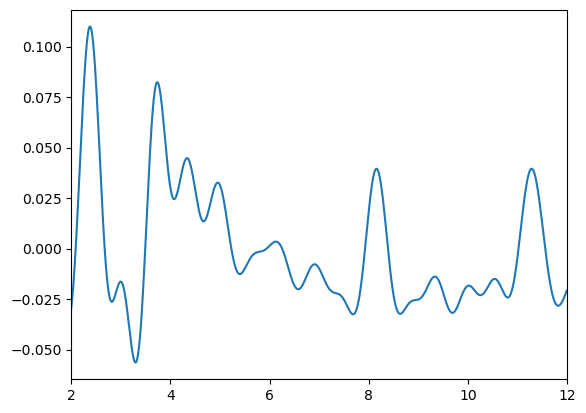

In [4]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files:
        if 'processed' in f:
            # For files containing 'processed' in their names (second type)
            df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        else:
            # For files not containing 'processed' in their names (first type)
            df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=0, engine='python')

        raw_data_points.append(df.values.ravel())
        if f[0] == 'p':
            labels.write('10')
            labels.write('\n')
        else:    
            labels.write(f[0])
            labels.write('\n')
raw_data_points = np.array(raw_data_points)

normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[13,:]))/100+2, data_points[13,:])
print(labels[13])

In [5]:
load_model.evaluate(data_points, labels)
y_pred_prob = load_model.predict(data_points)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(labels, y_pred)
recall = recall_score(labels, y_pred, average=None)
f1 = f1_score(labels, y_pred, average=None)
precision = precision_score(labels, y_pred, average=None)
print(np.unique(labels), np.unique(y_pred))
print('Confusion matrix \n', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

1/1 [==============================] - 0s 150ms/step - loss: 1.9197 - accuracy: 0.8000


2023-08-18 18:21:49.257123: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1/1 [==============================] - 0s 110ms/step
[ 3  4  6 10] [ 1  4  6  7 10]
Confusion matrix 
 [[ 0  0  0  0  0  0]
 [ 0  0  2  0  0  0]
 [ 0  0  1  0  1  1]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  0  0]
 [ 1  0  0  0  0 17]]
Recall score: [0.         0.         0.33333333 1.         0.         0.94444444]
F1 score: [0.         0.         0.33333333 1.         0.         0.94444444]
Precision score: [0.         0.         0.33333333 1.         0.         0.94444444]


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
